# DTL + MLForecast

Decomposed Trend-Local forecasting for non-seasonal panel time series. The DTL wrapper extracts a robust LOWESS trend, forecasts it with StatsForecast, and models the residual component with MLForecast.

In [1]:
import os
import sys
sys.path.append(os.path.abspath('../..'))

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, bias

from tinyshift.modelling import DTLWrapper
from tinyshift.plot import pami, residual_analysis, stationarity_analysis
from tinyshift.series import detrend, fva_rmae, forecast_instability, pbias, score, wape

In [2]:
metrics = [rmse, mae, bias, wape, pbias, score, forecast_instability]

## Build a non-seasonal panel

The example uses deterministic data so the notebook can run without downloading an external dataset.

In [3]:
rng = np.random.RandomState(42)
dates = pd.date_range('2018-01-01', periods=96, freq='MS')
rows = []
for unique_id, offset, slope in [('series_a', 20.0, 0.30), ('series_b', 35.0, -0.10)]:
    t = np.arange(len(dates), dtype=float)
    trend = offset + slope * t + 0.015 * t ** 2
    residual = 2.5 * np.sin(t / 2.5) + rng.normal(scale=0.7, size=len(t))
    rows.extend(zip([unique_id] * len(dates), dates, trend + residual))

df = pd.DataFrame(rows, columns=['unique_id', 'ds', 'y'])
df.head()

,unique_id,ds,y
0,series_a,2018-01-01,20.347700
1,series_a,2018-02-01,21.191761
2,series_a,2018-03-01,22.906772
3,series_a,2018-04-01,24.431219
4,series_a,2018-05-01,23.775027


In [4]:
horizon = 12
train = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[:-horizon], include_groups=True).reset_index(drop=True)
test = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[-horizon:], include_groups=True).reset_index(drop=True)

train.groupby('unique_id').size(), test.groupby('unique_id').size()

/tmp/ipykernel_15267/3675524071.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[:-horizon], include_groups=True).reset_index(drop=True)
/tmp/ipykernel_15267/3675524071.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test = df.groupby('unique_id', group_keys=False).apply(lambda group: group.iloc[-horizon:], include_groups=True).re

(unique_id
 series_a    84
 series_b    84
 dtype: int64,
 unique_id
 series_a    12
 series_b    12
 dtype: int64)

## Diagnose the detrended residual

DTL uses robust LOWESS to extract the trend before modelling the residual. The same detrended training signal can be inspected with stationarity analysis and PAMI to understand remaining autocorrelation, nonlinear dependence, and useful lag structure.

In [5]:
diagnostic_id = 'series_a'
diagnostic_train = train[train['unique_id'] == diagnostic_id].sort_values('ds')
diagnostic_components = detrend(
    diagnostic_train,
    frac=0.2,
    robust=True,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)
diagnostic_components.head()

,unique_id,ds,y,trend,detrended
0,series_a,2018-01-01,20.347700,22.198556,-1.850856
1,series_a,2018-02-01,21.191761,22.439609,-1.247848
2,series_a,2018-03-01,22.906772,22.653576,0.253196
3,series_a,2018-04-01,24.431219,22.845969,1.585250
4,series_a,2018-05-01,23.775027,23.023865,0.751162


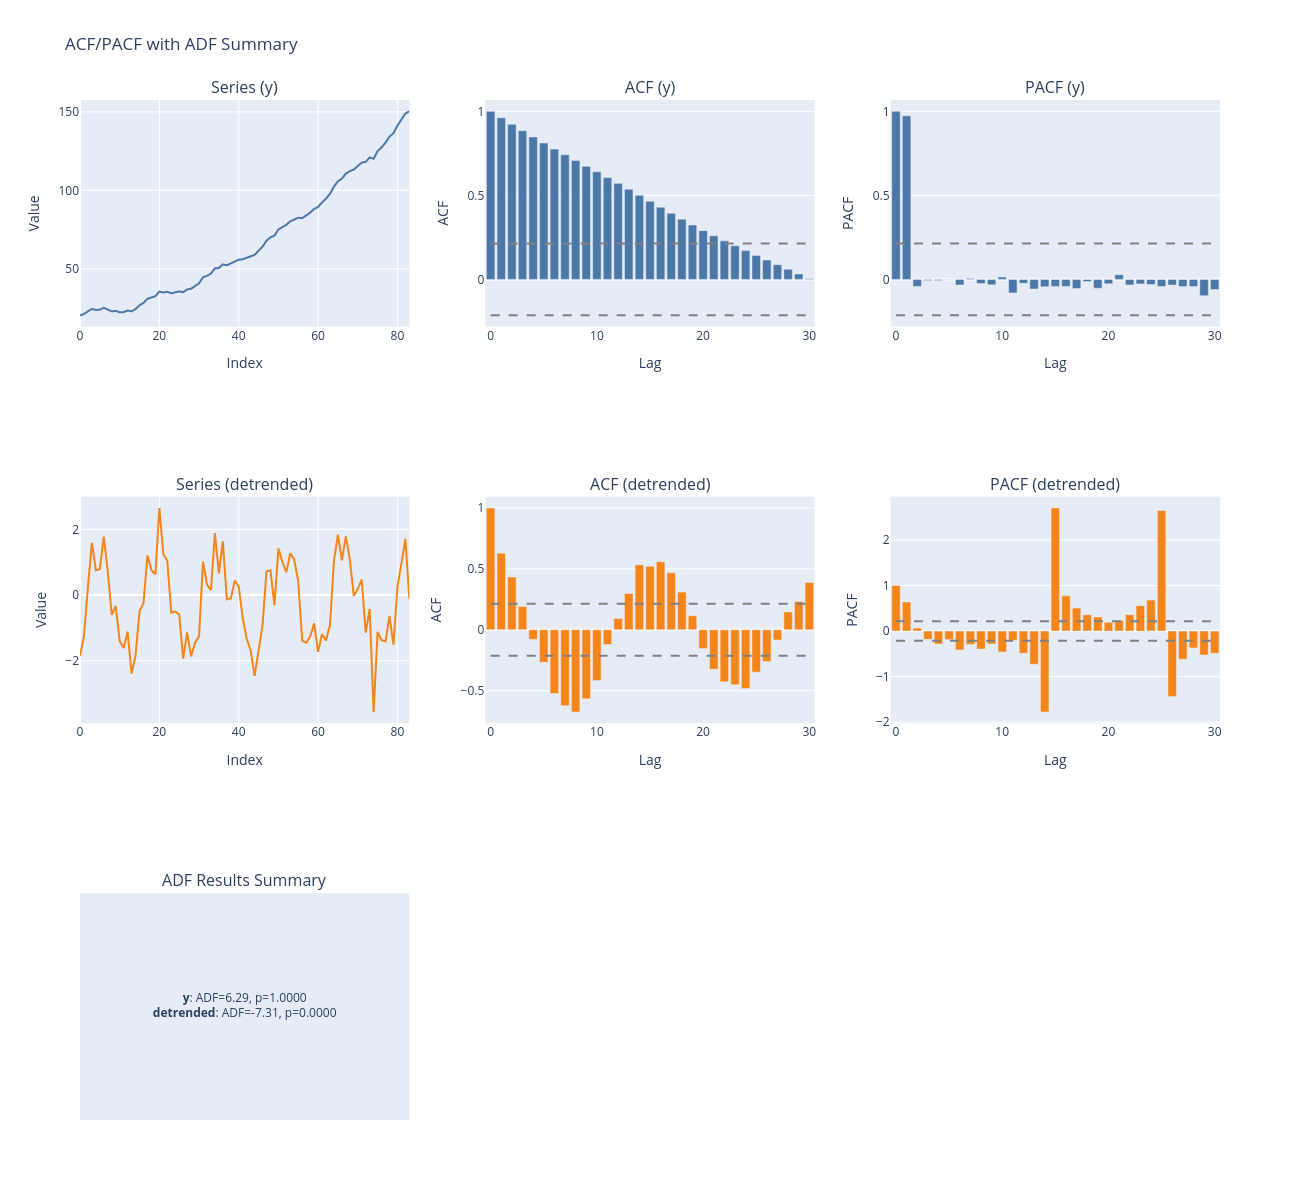

In [6]:
stationarity_analysis(
    diagnostic_components[['y', 'detrended']],
    nlags=30,
    fig_type='png',
)

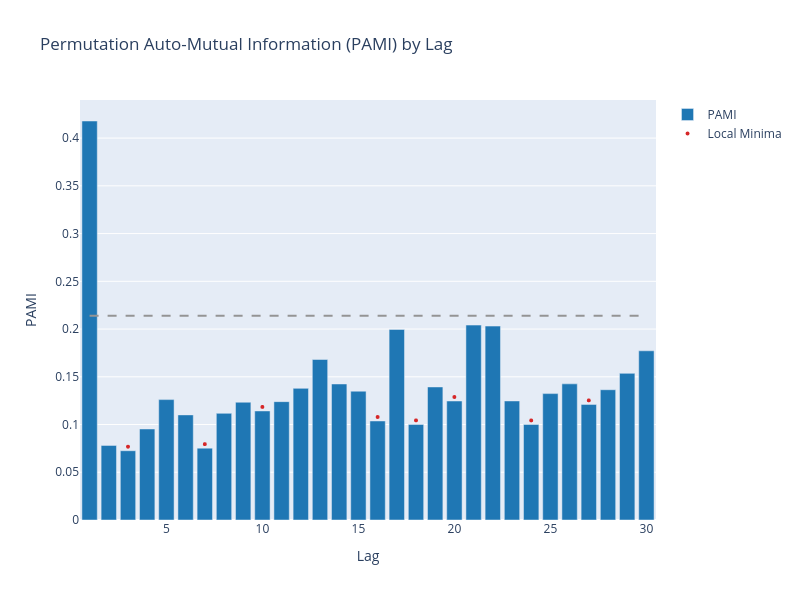

In [7]:
pami(
    diagnostic_components['detrended'],
    nlags=30,
    m=3,
    normalize=True,
    fig_type='png',
)

## Configure the residual forecaster

`mf_resid` is the unfitted residual-model template. DTL creates an isolated fitted copy for each `unique_id`.

In [8]:
residual_forecaster = MLForecast(
    models=[
        LinearRegression(),
        RandomForestRegressor(n_estimators=100, random_state=42),
    ],
    freq='MS',
    lags=[1, 3],
)

dtl = DTLWrapper(
    mf_resid=residual_forecaster,
    trend_frac=0.2,
    robust=True,
)

In [9]:
dtl.fit(train, id_col='unique_id', time_col='ds', target_col='y')

forecast = dtl.predict(h=horizon)
forecast.head()

/home/heylucasleao/tinyshift/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



,unique_id,ds,LinearRegression,RandomForestRegressor
0,series_a,2025-01-01,153.117405,154.180942
1,series_a,2025-02-01,155.882412,157.435443
2,series_a,2025-03-01,158.906639,159.602718
3,series_a,2025-04-01,161.924413,162.070694
4,series_a,2025-05-01,164.941833,165.710852


## Evaluate the forecasts

The wrapper preserves one prediction column per residual estimator.

In [10]:
actual = test[['unique_id', 'ds', 'y']]
result = forecast.merge(actual, on=['unique_id', 'ds'], how='left')

metrics = evaluate(
    result,
    metrics=metrics,
    models=['LinearRegression', 'RandomForestRegressor'],
    id_col='unique_id',
    time_col='ds',
    target_col='y',
)
metrics

,unique_id,metric,LinearRegression,RandomForestRegressor
0,series_a,rmse,3.296102,2.922553
1,series_b,rmse,5.082891,5.550267
2,series_a,mae,2.963423,2.717491
3,series_b,mae,4.817395,5.223820
4,series_a,bias,2.963423,2.717491
5,series_b,bias,4.817395,5.223820
6,series_a,wape,1.780892,1.633097
7,series_b,wape,3.308598,3.587732
8,series_a,pbias,1.780892,1.633097
9,series_b,pbias,3.308598,3.587732


## Forecast residual analysis

After recombining the LOWESS trend with the ML residual forecast, inspect the remaining forecast errors for each estimator.

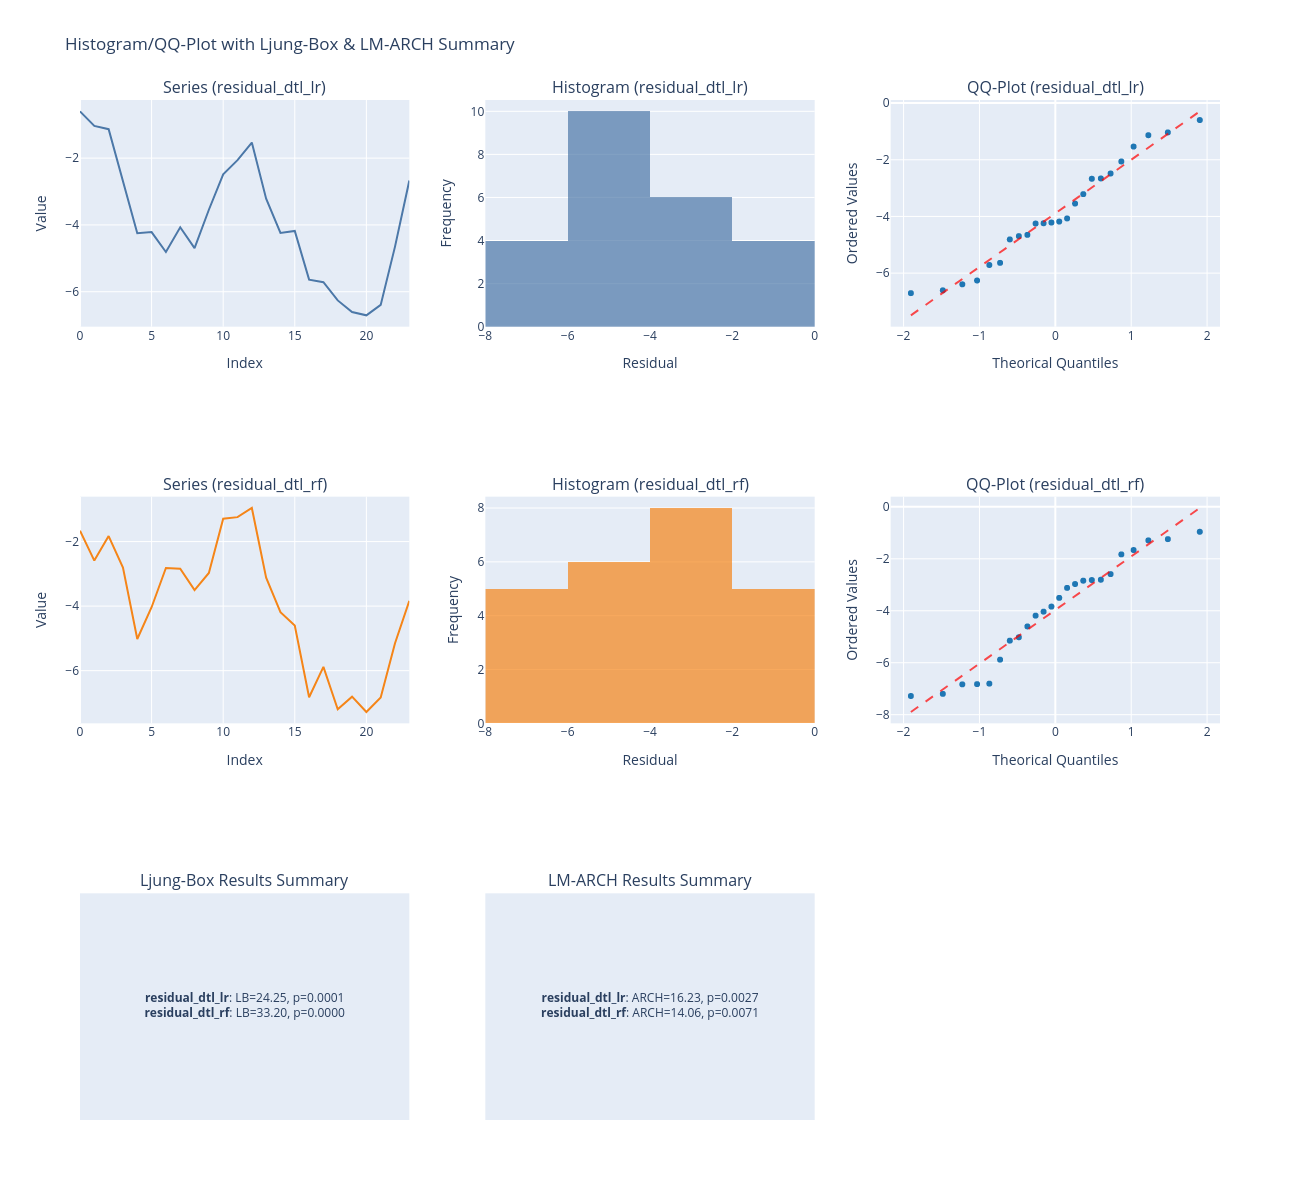

In [11]:
result['residual_dtl_lr'] = result['y'] - result['LinearRegression']
result['residual_dtl_rf'] = result['y'] - result['RandomForestRegressor']

residual_analysis(
    result[['residual_dtl_lr', 'residual_dtl_rf']],
    nlags=30,
    fig_type='png',
)

## Horizontal stabilization

Stabilization can be applied after trend and residual recombination.

In [12]:
stabilized = dtl.predict(
    h=horizon,
    stabilization_method='hfi',
    w_s=0.8,
)[['unique_id', 'ds', 'RandomForestRegressor']]

stabilized.head()

,unique_id,ds,RandomForestRegressor
0,series_a,2025-01-01,154.180942
1,series_a,2025-02-01,154.831842
2,series_a,2025-03-01,155.786017
3,series_a,2025-04-01,157.042953
4,series_a,2025-05-01,158.776532


In [13]:
rf_prediction = result['RandomForestRegressor'].to_numpy()
actual_values = result['y'].to_numpy()
fva_rmae(actual_values, rf_prediction, baseline_type='naive')

0.8747903889399591